# Project Notebook

This notebook contains the tasks for the project, organized chronologically.

## 1. Data Collection
- **Web Scraping**
- **OCR**
- **Translation**

---

## 2. Data Annotation
- Annotate with the following:
  - **Value** 
  - **Age**
  - **Title**
  - **Does it align with Islamic values?** Provide a reason.
- Create a **Prompt** column for the manually gathered data.

---

## 3. Fine-Tuning
- **Final Dataset Preparation**
- Configure **LoRA Parameters**
- **Quantization and Optimization** for inference
- Push the model to **Hugging Face**

---

## 4. Inference Pipeline
- Provide a **Code Snippet** for the backend implementation.


--- 
---


##  Data collection

## 1. Web Scrapping: 

In the following code, we demonstrate an example of web scraping a website called **al-Hakawati** using the Scrapy framework.  

- The spider, named **Hakawaty**, targets specific categories such as "قصص للصغار" and "ألف ليلة وليلة."  
- It navigates through the website, extracts story titles and content, and processes them into a structured format.  
- The extracted data is passed through a custom pipeline for further handling.  

This implementation highlights the use of XPath for data extraction and Scrapy's pipeline for efficient data processing.

Check the full code at https://github.com/RaidOuahioune/story-scrapper


and You can check the result of the scrapping in this link :https://drive.google.com/drive/folders/1qooJb_Wt_Hrcanc57l1Ld0s7ooxGkfsN



In [ ]:
! pip install scrapy

In [ ]:
import scrapy


class HakawatySpider(scrapy.Spider):
    name = "hakawaty"
    allowed_domains = ["al-hakawati.net"]
    start_urls = ["https://al-hakawati.net/Stories/"]

    CATEGORY_NAME_XPATH = ".//span[@class='title-6']/text()"
    STORY_TABLE_ROWS_XPATH = "//table"
    CATEGORY_DIV_XPATH = "/html/body/div[2]/div[2]/div[3]/span"
    STORY_TITLE_XPATH = ".//span[@class='title-5']"
    STORY_CONTENT_XPATH = ".//span/p"
    children_categories = ["قصص للصغار", "ألف ليلة وليلة"]

    custom_settings = {
        "ITEM_PIPELINES": {
            "main.pipelines.HakawatyPipeline": 1,
        }
    }

    def parse(self, response: scrapy.http.response.Response):
        categories = response.xpath(self.CATEGORY_DIV_XPATH)
        for category in categories:
            category_name = category.xpath(self.CATEGORY_NAME_XPATH).get().strip()

            category_link = category.xpath(".//a/@href").get()
            if category_name in self.children_categories and category_link is not None:

                yield response.follow(
                    category_link,
                    self.parse_category,
                    meta={"category_name": category_name},
                )

    def parse_category(self, response: scrapy.http.response.Response):
        category_name = response.meta["category_name"]
        stories = []

        table = response.xpath(self.STORY_TABLE_ROWS_XPATH)
        story_rows = table.xpath(".//tr")

        for row in story_rows:
            story_link = row.xpath(".//td/a/@href").get()
            if story_link:
                yield response.follow(
                    story_link, self.parse_story, meta={"category_name": category_name}
                )

    def parse_story(self, response: scrapy.http.response.Response):
        category_name = response.meta["category_name"]

        story_title_element = response.xpath(self.STORY_TITLE_XPATH)
        story_title = story_title_element.xpath("text()").get(default="").strip()

        story_content_element = response.xpath(self.STORY_CONTENT_XPATH)
        story_content = "\n".join(
            story_content_element.xpath(".//text()").getall()
        ).strip()
        story_content = story_content.replace("\n", " ").replace("  ", " ")

        if story_title and story_content:
            story_data = {
                "title": story_title,
                "content": story_content,
            }
            yield {category_name: story_data}

## 2. OCR  

To achieve optimal results with OCR, we utilized the **Tesseract** library. The process was as follows:  

1. **Image Splitting**: Each image was divided into smaller, manageable segments.  
2. **Segment OCR**: Optical Character Recognition (OCR) was performed on each segment individually.  
3. **Text Aggregation**: The extracted text from all segments was combined to reconstruct the complete story.  

This approach ensures higher accuracy by focusing on smaller regions, reducing errors caused by large or complex layouts.



check the resulted dataset here : https://drive.google.com/drive/folders/1HtLL5QaYGe_Ib1vLgBSfHW3thH_QpS4P


### a. Splitting the images

In [ ]:
! pip install PIL cv2 pytesseract numpy

In [ ]:
import os
import cv2
from PIL import Image
import pytesseract
from pytesseract import Output
import numpy as np
import re


def split_image_with_ocr(input_folder, output_folder):
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            input_image = os.path.join(input_folder, filename)

            # Read the image using OpenCV
            img = cv2.imread(input_image)

            if img is None:
                print(f"Failed to load {filename}")
                continue

            # Convert the image to RGB format (OpenCV loads images in BGR format)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Convert the NumPy array (OpenCV image) to a PIL Image
            pil_img = Image.fromarray(img_rgb)

            # Perform OCR on the image to get bounding boxes for the text
            data = pytesseract.image_to_data(pil_img, output_type=Output.DICT)

            # Extract the y-coordinates (top positions) and heights of each text box
            heights = data["top"]
            text_heights = data["height"]

            # Sort the y-coordinates of the text boxes
            heights_sorted = sorted(heights)

            # Calculate split points based on gaps between text boxes
            split_gap = 20  # Adjust this depending on the size of gaps in your images

            # Identify two split points based on the largest gaps between text boxes
            split_points = []
            for i in range(len(heights_sorted) - 1):
                gap = heights_sorted[i + 1] - (heights_sorted[i] + text_heights[i])
                if gap > split_gap:
                    split_points.append(heights_sorted[i + 1])
                if len(split_points) == 2:  # We only need two split points
                    break

            # If we couldn't find enough split points, skip this image
            if len(split_points) < 2:
                print(f"Error: Could not find enough split points for {filename}.")
                continue

            # Split the image into three parts
            top_part = img[: split_points[0], :]
            middle_part = img[split_points[0] : split_points[1], :]
            bottom_part = img[split_points[1] :, :]

            # Check if any of the parts are empty
            if top_part.size == 0 or middle_part.size == 0 or bottom_part.size == 0:
                print(f"Error: Image {filename} split failed, empty part found.")
                continue

            # Create output filenames
            base_filename = os.path.splitext(filename)[0]
            output_top = os.path.join(output_folder, f"{base_filename}_top.png")
            output_middle = os.path.join(output_folder, f"{base_filename}_middle.png")
            output_bottom = os.path.join(output_folder, f"{base_filename}_bottom.png")

            # Save the three parts as separate images
            cv2.imwrite(output_top, top_part)
            cv2.imwrite(output_middle, middle_part)
            cv2.imwrite(output_bottom, bottom_part)

            print(
                f"Image {filename} split and saved as {output_top}, {output_middle}, and {output_bottom}."
            )


### b. The OCR code : 
Here is an example extracted using OCR :


'''
في إحدى المدن تم افتتاح متجر لبيع الأزواج حيث يمكن للمرأة الذهاب
لاختيار زوج بنفسها ومن بين التعليمات التي وضعت في المدخل حول
أسلوب عمل المتجر: أن للمرأة فرصة الدخول مرة واحدة للمتجر .

ويمكن الاختيار من أحد الطوابق أو الذهاب إلى الطابق الأخر الأعلى


منه ولكن لا يمكن النزول إلى أسفل دخلت إحدى النساء )لمتجر


الأزواج لاختيار زوج لها في مدخل الطابق الأول علامة : الرجال هنا
لديهم عمل ومؤمنون بالله وفي مدخل الطابق الثاني علامة : الرجال
هنا لديهم عمل ومؤمنون بالله ويحبون أطفالهم وفي مدخل الطابق
الثالث علامة : الرجال هنا لديهم عمل ومؤمنون بالله ويحبون أطفالهم
وشكلهم جذاب وكانت المرأة تفكر 'واو ولكن سأستمر بالصعود وقد
وصلت إلى الطابق الرابع لتجد علامة : الرجال هنا لديهم عمل
ومؤمنون بالله ويحبون أطفالهم وشكلهم جذاب ويساعدون زوجاتهم
في أعمال المنزل فتعجبت في خلجات نفسها ' يا إلهي إني لا أستطيع
التحمل سأوافق ' ولكنها استمرت بالصعود وفي مدخل الطابق
الخامسوجدت علامة : الرجال هنا لديهم عمل ومؤمنون باللهويحبون
أطفالهم وشكلهم جذاب ولهم قابلية رومانسيةعالية لمغازلة زوجاتهم
دائما وكادت أن تطأ قدمها ذلك الطابق إلا أنها استمرت بالصعود وفي
مدخل الطابق السادس وجدت علامة : أنت الزائرة رقم 912.363.4
كبرهان ان النساء لا يمكن إرضاؤهم شكرا للتسوق في 'متجر الازواج
وانتبهي لخطواتك وأنت تخرجين ونتمنى لك يوما سعيدا.
'''

In [ ]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
def is_title_candidate(line, previous_line):
    stripped_line = line.strip()
    # Check for numbers, short length, no punctuation at the end, and previous line is empty
    if (
        len(stripped_line) > 0
        and len(stripped_line.split()) <= 5
        and not re.search(r"\d", stripped_line)  # Avoid numbers
        and not stripped_line.endswith((".", "؟", "!", ":"))  # Avoid ending punctuation
        and len(previous_line.strip()) == 0
    ):  # Check if the previous line is empty
        return True
    return False


def png_to_txt_with_titles(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(".png"):
            img_path = os.path.join(input_folder, filename)
            img = Image.open(img_path)
            text = pytesseract.image_to_string(img, lang="ara", config="--psm 6z")

            processed_lines = []
            lines = text.split("\n")
            for i, line in enumerate(lines):
                if i == 0:
                    previous_line = ""
                else:
                    previous_line = lines[i - 1]

                if is_title_candidate(line, previous_line):
                    line = f"<title>{line.strip()}</title>"

                processed_lines.append(line.strip())

            txt_filename = f"{os.path.splitext(filename)[0]}.txt"
            txt_path = os.path.join(output_folder, txt_filename)

            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(processed_lines))

            print(f"Processed {filename} -> {txt_filename}")



## The above manual datasets gathered are all stoed in this drive organized by the data collected by each member : 
https://drive.google.com/drive/folders/1xU_zYZUPBKY7GhlvFFCXbdUEtxmnfvBg

## 3. Translation

We kept track of the last processed story , so that the next kaggle session will start from where we have stoped , it took around  50 hours to translate the whole dataset including both the story and the prompt , in which now we have around 900k translated arabic story in total.

Here is the dataset used for translation : https://huggingface.co/datasets/ajibawa-2023/Children-Stories-Collection


and here is the final dataset resulted after the translation :
https://www.kaggle.com/datasets/raidouahioune/translated-arabic-children-stories


In [ ]:
from datasets import load_dataset

import mtranslate.core as mt
import json

ds = load_dataset("ajibawa-2023/Children-Stories-Collection")
session_max_lenght = 130000
notebook_index = 5
samples = ds["train"]["prompt"]
translated_samples = []
failed_samples = []

size_1 = 100000

for i, sample in enumerate(
    samples[
        session_max_lenght * notebook_index
        + size_1 : (notebook_index + 1) * session_max_lenght
    ]
):
    try:
        # Translating the sample to Arabic
        translated_text = mt.translate(sample, "ar")
        translated_samples.append(
            [i + session_max_lenght * notebook_index, translated_text]
        )
    except Exception as e:

        failed_samples.append(i + session_max_lenght * notebook_index)


with open("translated_prompts.json", "w", encoding="utf-8") as f:
    json.dump(translated_samples, f, ensure_ascii=False, indent=4)

with open("failed_promts.json", "w") as f:
    json.dump(failed_samples, f, indent=4)


##  Data Annotation

## 1 . Age and value annotation :
we have used ollama and gemma2-9b to process the stories 


In [ ]:

'''
Installing the required packages
'''
! curl -fsSL https://ollama.com/install.sh | sh
! pip install mtranslate
! pip install ollama

In [ ]:
'''
running the ollama server in the background of the kaggle session and pulling the required model
 '''
import subprocess
process = subprocess.Popen("ollama serve", shell=True)

! ollama pull gemma2:9b 

## Observations on Translation Quality  

While using the Google Translation API, we noticed the following issues:  
- Some proper nouns, such as **capital names**, were left in **Latin characters** instead of being translated into Arabic.  

### Addressing the Issue  

1. **Initial Solution: Transliteration**  
   - Transliteration was considered as a possible approach to convert Latin characters into Arabic.  
   - However, this method proved **error-prone**, especially when the Arabic equivalent of a word differs significantly from its Latin form (e.g., *Egypt* → *مصر*).  

2. **Enhanced Solution: Leveraging LLMs**  
   - To resolve this, we utilized the **Gemma2-9b** large language model (LLM) to accurately translate any remaining Latin words into Arabic.  
   - This approach ensured context-aware translation, providing **more reliable results** for names and other untranslated terms.  

By integrating LLMs into the pipeline, we successfully addressed the limitations of standard translation methods and improved the overall accuracy of the text.


In [ ]:
from ollama import chat, ChatResponse


def translate_latin_to_arabic_llm(text):
    """
    Translate Latin (English) words in the text to Arabic using an LLM, specifically targeting names or other key words.
    """

    def format_translation_prompt(words):
        return f"""
        أنت مترجم محترف. النص التالي يحتوي على كلمات باللغة الإنجليزية (اللاتينية) التي تحتاج إلى ترجمة دقيقة إلى العربية. يرجى ترجمة الكلمات الإنجليزية فقط إلى اللغة العربية، مع الحفاظ على النص العربي كما هو.

        ### النص:
        {", ".join(words)}

        ### تعليمات:
        - قم بترجمة الكلمات الإنجليزية فقط إلى العربية.
        - لا تضف أي نص إضافي أو تفسير.
        - أعد الترجمة كقائمة واحدة، مع كل كلمة مترجمة في سطر منفصل.
        """

    # Extract Latin words (names) from the input text using a pattern
    latin_word_pattern = r"\b[A-Za-z]+\b"
    latin_words = re.findall(latin_word_pattern, text)
    print(latin_words)
    if not latin_words:

        return text  # If no Latin words found, return the original text

    # Prepare the prompt for translation
    prompt = format_translation_prompt(latin_words)

    # Call the LLM for translation
    response: ChatResponse = chat(
        model="gemma2:9b",
        messages=[
            {
                "role": "user",
                "content": prompt,
            },
        ],
    )

    # Parse the response to map translations back into the text
    translations = response.message.content.strip().split("\n")
    translation_map = dict(zip(latin_words, translations))

    # Replace the Latin words in the original text with their translations
    def replace_with_translation(match):
        return translation_map.get(match.group(0), match.group(0))

    return re.sub(latin_word_pattern, replace_with_translation, text)

### Text Normalization and Preprocessing  

The provided code performs **normalization** and **preprocessing** on Arabic text to prepare it for further analysis or use.  

1. **Normalization**:  
   - The `normalize_arabic` function replaces certain Arabic characters with standardized forms (e.g., replacing "أ" or "ا" with "آ").  

2. **Preprocessing Steps**:  
   - Handles missing values to prevent errors.  
   - Removes unwanted elements such as:
     - Code blocks (` ```...``` `).  
     - HTML tags (`<...>`).  
     - Excessive or escaped newlines.  
   - Translates Latin words (e.g., proper nouns) to Arabic using a function like `translate_latin_to_arabic_llm`.  
   - Cleans up non-Arabic characters, keeping only Arabic text and punctuation.  
   - Normalizes whitespace for cleaner formatting.  

These steps ensure the text is cleaned, standardized, and ready for downstream tasks.


In [ ]:
import re
import pandas as pd


def normalize_arabic(text):
    """Normalize Arabic text by replacing similar characters."""
    text = re.sub(r"أا", "آ", text)
    # text = re.sub(r'ى', 'ي', text)
    # text = re.sub(r'ؤ', 'و', text)
    # text = re.sub(r'ئ', 'ي', text)
    # text = re.sub(r'ة', 'ه', text)
    return text

def preprocess_story(story):
    if pd.isnull(story):  # Handle missing values
        return None
    # story = remove_diacritics(story)
    story = normalize_arabic(story)
    # Remove unwanted characters and formatting
    story = re.sub(r"```.*?```", "", story, flags=re.DOTALL)  # Remove code blocks
    story = re.sub(r"<.*?>", "", story)  # Remove HTML tags
    story = re.sub(r"\n+", "\n", story).strip()  # Remove excessive newlines
    story = re.sub(r"\\n", " ", story)  # Replace escaped newlines with space
    # First, translate Latin words between quotes to Arabic
    story = translate_latin_to_arabic_llm(story)
    # Now, apply the original cleaning regex (remove non-Arabic characters)
    story = re.sub(r"[^\u0600-\u06FF\s.,!?،]", "", story)
    # story = re.sub(r'[^\u0600-\u06FF\s.,!?،]', '', story)  # Keep only Arabic chars and punctuation
    story = re.sub(r"\s+", " ", story).strip()  # Normalize whitespace
    return story

The following code defines the prompt we have used as an input for the model.

### Key Objectives:

1. **Formatting the Input**:  
   The first function, `format_input`, dynamically inserts the story into the prompt template. This allows us to customize the input for different stories without manually altering the template each time.

2. **Extracting Key Values**:  
   The `extract_values` function is designed to parse the output of the model and extract important details such as:
   - **Compatibility with Islamic Values**: Whether the story aligns with key ethical principles.
   - **Appropriate Age Range**: Based on the complexity and themes of the story, we determine the recommended age group.
   - **Reason for Incompatibility**: If the story violates any values, the reason is extracted.
   - **Moral Value of the Story**: The underlying message or value conveyed (e.g., honesty, cooperation).

In [ ]:
# prompot

prompt = """ اقرأ القصة التالية بعناية. مهمتك هي تحديد ما إذا كانت القصة تتوافق مع القيم الإسلامية الأساسية، وتحديد الفئة العمرية المناسبة لها. القصة لا تحتاج إلى تضمين جميع النقاط التالية، ولكن إذا تناولت أيًا منها، فيجب أن تكون متوافقة مع القيم والمبادئ الإسلامية.

### المعايير التي يجب مراعاتها:

#### الأخلاق الإسلامية:
- يجب أن تلتزم القصة بمبادئ الصدق، العدل، الأمانة، الإحسان، والتواضع.
- إذا تضمنت القصة علاقات اجتماعية، فيجب أن تكون في إطار الحلال (مثل الزواج الشرعي)، مع تجنب العلاقات المحرمة مثل الصداقة بين الشاب والفتاة خارج الزواج.

#### الأطعمة والمشروبات:
- إذا تناولت القصة موضوع الطعام أو الشراب، فيجب أن تلتزم بالأطعمة والمشروبات الحلال، وتجنب ذكر أو الترويج للمحرمات (مثل لحم الخنزير أو الكحول).

#### العقيدة الإسلامية:
- إذا تطرقت القصة إلى موضوع العقيدة أو المعتقدات، فيجب أن تركز على التوحيد (الإيمان بالله وحده) وألا تروج للشرك بالله بأي شكل (مثل عبادة غير الله أو الاعتماد على قوى محرمة).

#### احترام وبر الوالدين:
- يجب أن تشجع القصة على احترام وبر الوالدين، وعدم تقديم أي رسائل ضمنية أو مباشرة تعارض هذا المبدأ.

---
### المعايير لاختيار الفئة العمرية:  

1. **الفئة العمرية 3-5:**  
   - اللغة: بسيطة جدًا، مع كلمات أساسية ومفردات محدودة.  
   - الحبكة: قصيرة للغاية وسهلة الفهم.  
   - الشخصيات: غالبًا ما تكون حيوانات أو كائنات كرتونية محببة للأطفال.  
   - المواضيع: تركز على المفاهيم الأساسية مثل المشاركة، النظافة، أو الطاعة.  
   - لا تتطلب القصة التفكير النقدي أو معالجة موضوعات معقدة.  

2. **الفئة العمرية 6-8:**  
   - اللغة: متوسطة التعقيد، تتضمن مفردات أكثر تنوعًا لكنها واضحة.  
   - الحبكة: أطول نسبيًا، مع شخصيات متعددة أو أحداث مترابطة.  
   - المواضيع: تقدم دروسًا أخلاقية مثل التعاون، الشجاعة، أو الصدق.  
   - القصة قد تحتوي على مواقف اجتماعية بسيطة (داخل العائلة أو بين الأطفال).  

3. **الفئة العمرية 9-10:**  
   - اللغة: أكثر تقدمًا، مع جمل طويلة ومفردات غنية.  
   - الحبكة: معقدة أو تتناول مواضيع تتطلب التفكير النقدي.  
   - المواضيع: تعالج قضايا اجتماعية، حل المشكلات، أو أفكار أعمق.  
   - القصة قد تحتوي على مواقف حياتية واقعية تستدعي تحليلاً أكبر.  

---
### المطلوب:
1. إذا كانت القصة تتوافق مع هذه القيم ولم تتعارض معها، أجب بـ "True" مع تعيين عنوان مناسب للقصة.
2. إذا تضمنت أي عناصر تتعارض مع القيم الإسلامية، مثل الترويج للمحرمات أو الانحراف عن العقيدة، أجب بـ "False"، مع تحديد الأسباب التي تجعل القصة غير مناسبة.
   - يجب أن تتضمن الأسباب المعايير التي تم انتهاكها من بين المعايير المذكورة أعلاه (الأخلاق الإسلامية، الأطعمة والمشروبات، العقيدة الإسلامية، احترام وبر الوالدين).
3. حدد الفئة العمرية المناسبة للقصة استنادًا إلى محتواها من بين هذه الفئات:
   - 3-5 سنوات
   - 6-8 سنوات
   - 9-10 سنوات
   - أكثر من 10 سنوات
4. إذا كانت القصة غير مناسبة (الإجابة "False")، يجب أن تكون الفئة العمرية "None".
5. إذا كانت القصة مناسبة للقيم الإسلامية، يجب إعطاء قيمة مميزة تعكس موضوع القصة مثل "الصدق"، "التسامح"، "الشجاعة"، "التعاون"، إلخ.
6. تقديم عنوان مناسب للقصة يعكس مضمونها.

---
IMPORTANT !: DO NOT ADD ANY EXTRA TEXT AND YOU MUST STRICTLY FOLLOW THE OUTPUT TEMPLATE AND BE AS BRIEF AS POSSIBLE!
### الناتج المطلوب (Output Template):

- هل القصة متوافقة مع القيم الإسلامية؟: @[True/False]@
- السبب (إذا كانت الإجابة "False"): حدد النقاط التي تعارض القيم الإسلامية من خلال ذكر المعيار/المعايير التي تم انتهاكها (مثل: الأخلاق الإسلامية، الأطعمة والمشروبات، العقيدة الإسلامية، احترام وبر الوالدين).
- الفئة العمرية المناسبة: @[الفئة العمرية المناسبة أو None]@
- العنوان المناسب للقصة: @[عنوان القصة المناسب]@
- القيمة المميزة: @[قيمة القصة مثل "الصدق"، "التسامح"، "الشجاعة"، "التعاون"، إلخ]@

**عند الإجابة "True":**
- هل القصة متوافقة مع القيم الإسلامية؟: True
- الفئة العمرية المناسبة: @[الفئة العمرية المناسبة]@
- العنوان المناسب للقصة: @[عنوان القصة المناسب]@
- القيمة المميزة: @[قيمة القصة مثل "الصدق"، "التسامح"، "الشجاعة"، "التعاون"، إلخ]@
**عند الإجابة "False":**
- هل القصة متوافقة مع القيم الإسلامية؟: False
- السبب: حدد النقاط التي تعارض القيم الإسلامية من خلال ذكر المعيار/المعايير التي تم انتهاكها (مثل: الأخلاق الإسلامية، الأطعمة والمشروبات، العقيدة الإسلامية، احترام وبر الوالدين) دون تقديم شرح إضافي للمعيار/المعايير.
- الفئة العمرية المناسبة: None
- العنوان المناسب للقصة: @[عنوان القصة المناسب]@
- القيمة المميزة: None

---

### القصة:
"{نص القصة هنا}"
"""


def format_input(prompt, story):
    return prompt.replace("{نص القصة هنا}", story)


def extract_values(output):
    # Match for title
    title_match = re.search(
        r'- ?(?:العنوان المناسب للقصة| \*\*العنوان المناسب للقصة\*\*):\s*["]?(.*?)(?=["]?\s*(?:$|\n))',
        output,
    )
    # Match for age range
    age_range_match = re.search(r"الفئة العمرية المناسبة:\s*(\d+-\d+)\s*", output)
    # Match for compatibility
    compatible_match = re.search(
        r"- ?هل القصة متوافقة مع القيم الإسلامية\؟:\s*(True|False)\s*", output
    )
    # Match for reason (if False)
    reason_match = (
        re.search(r"السبب:\s*(.*?)\s*(?=\n|$)", output) if "False" in output else None
    )
    # Match for value (if present)
    value_match = re.search(r"القيمة المميزة:\s*(.*?)\s*(?=\n|$)", output)
    # Extract values or set as None if not found
    title = title_match.group(1) if title_match else ""
    age_range = age_range_match.group(1) if age_range_match else ""
    is_compatible = compatible_match.group(1) if compatible_match else ""
    reason = reason_match.group(1) if reason_match else ""
    value = value_match.group(1) if value_match else ""
    return title, age_range, is_compatible, reason, value

In [ ]:
'''this is the function that will be used to label the story and return the required values'''
from ollama import chat
from ollama import ChatResponse
def label_story(story):
    input_text = format_input(prompt, story)
    response: ChatResponse = chat(
        model="gemma2:9b",
        messages=[
            {
                "role": "user",
                "content": input_text,
            },
        ],
    )
    output = response.message.content
    print(output)
    title, age_range, is_compatible, reason, value = extract_values(output)
    return title, age_range, is_compatible, reason, value



The processing of the translated dataset to construct these columns have produced the following dataset in which will be using later for the fine tuning: 
https://www.kaggle.com/datasets/raidouahioune/final-arabic-stories-dataset

It should be mentioned that each member of the team has taken 10k stories at least to process 

## 2. Prompt Column Extraction  

In the previous annotation approach, we assumed that we had two columns: the story and the prompt, which we used to extract other related fields. In this improved approach, we assume that all columns are available, **except the prompt field**, which we aim to generate automatically.

This method was applied to the dataset we manually gathered using the techniques discussed in the **Data Gathering** section (including **web scraping** and **OCR**). In this process, we manually labeled the other fields after reading each story, but we faced a challenge: **creating a specialized context prompt for each story**.

### Automation for Contextual Prompt Generation

To overcome this challenge, we leveraged the power of the **Gemini** model. By using the existing columns—**story**, **title**, **value**, and **age**—we used the model to automatically generate relevant prompts. This approach not only **speeds up the annotation process** but also ensures that the generated prompts are **contextually aligned** with the content of each story.


In [ ]:
'''THis is the prompt used to get the prompt for the story'''


prompt_to_generate_a_prompt = """اقرأ القصة التالية بعناية. مهمتك هي إنشاء نموذج (prompt) يمكنني استخدامه لطلب إنشاء هذه القصة مرة أخرى بنفس التنسيق.
---
IMPORTANT !: DO NOT ADD ANY EXTRA TEXT AND YOU MUST STRICTLY FOLLOW THE OUTPUT TEMPLATE AND BE AS BRIEF AS POSSIBLE!
### الناتج المطلوب (Output Format and Example):
General Format:
prompt:
-"اكتب قصة تعليمية موجهة للأطفال ({الهدف العمري}) باستخدام اللغة العربية. يجب أن تكون القصة مستوحاة من مقتطف النص التالي:

""{ ملخص القصة أو المقتطف المحوري}""

لا يجب أن تتناول القصة كل شيء في المقطع، فهي موجودة فقط للإلهام.

يجب أن تحتوي القصة على الميزات التالية:
- {الميزة الأولى}
- {الميزة الثانية}
- {الميزة الثالثة}
Endprompt

### Example:
prompt:
-"اكتب قصة تعليمية موجهة للأطفال من سن 5 إلى 8 باستخدام كلمات بسيطة. يجب أن تكون القصة مستوحاة من مقتطف النص التالي:

""ناقش التأثيرات النفسية لمشاهدة أفلام الرعب على المشاهدين.

يمكن لأفلام الرعب أن تثير مجموعة من التأثيرات النفسية على المشاهدين. يمكن أن تختلف هذه التأثيرات حسب الفرد وتجاربه الشخصية، ولكن بعض التأثيرات الشائعة قد تشمل:

1. الخوف والقلق: تم تصميم أفلام الرعب لتخويف المشاهدين وغالبًا ما تنطوي على صور دموية أو مزعجة. نتيجة لذلك، قد يشعر المشاهدون بالخوف والقلق أثناء مشاهدة هذه الأفلام. يمكن لهذا الخوف أن ينشط استجابة القتال أو الهروب، مما يؤدي إلى زيادة معدل ضربات القلب والتعرق وأعراض جسدية أخرى للقلق.

2. إزالة الحساسية: يمكن أن تؤدي مشاهدة أفلام الرعب بشكل متكرر إلى إزالة حساسية المشاهدين تجاه الخوف والعنف الذي يتم تصويره في هذه الأفلام. وهذا يعني أن المشاهدين قد يصبحون أقل تفاعلاً مع هذه المحفزات بمرور الوقت وقد يحتاجون إلى محتوى أكثر تطرفًا لإثارة نفس مستوى الخوف أو القلق.

3. الكوابيس واضطرابات النوم: يمكن لأفلام الرعب أيضًا أن تعطل أنماط النوم وتؤدي إلى الكوابيس.

لا يجب أن تتناول القصة كل شيء في المقطع، فهي موجودة فقط للإلهام.

يجب أن تحتوي القصة على الميزات التالية:
- دمج العلوم: تضمين المفاهيم العلمية الأساسية داخل القصة، وشرحها من خلال مغامرات الشخصيات واكتشافاتها.
- الشخصيات والحوار: إنشاء شخصيات لا تُنسى تشارك في محادثات ذات مغزى، مما يساعد في شرح واستكشاف المفاهيم العلمية.
- تحول غير متوقع: تنتهي بتحول لا يحل كما هو متوقع، لكنه يترك درسًا واضحًا عن الحياة والعلم."
Endprompt


### القصة:
"{نص القصة هنا}"
### المميزات:
"{المميزات هنا}"
### الهدف العمري:
"{الهدف العمري هنا}"
"""

The resulted dataset was concatenated with this one https://www.kaggle.com/datasets/raidouahioune/final-arabic-stories-dataset directly

## Fine Tuning :

Now assuming we have a dataset that contains  these columns : story, title, age,value,is_islamic,reason 
We will fine tune the qwen7.5B-it using Qlora and the library unsloth.


In [ ]:
'''Here we load the quantized version of the model'''

from unsloth import FastLanguageModel
import torch

max_seq_length = 2048  
dtype = (
    None  # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
)
load_in_4bit = True  # Use 4bit quantization to reduce memory usage. Can be False.
hf_token = "YOUR HUGGINGFACE TOKEN"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hf_token,
)


In [ ]:
'''here we set the parameters of the Lora Config'''

model = FastLanguageModel.get_peft_model(
    model,
    r=32,  # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128  ##
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,  ##
    lora_dropout=0,  # Supports any, but = 0 is optimized
    bias="none",  # Supports any, but = "none" is optimized
    use_gradient_checkpointing=True,
    random_state=3407,
    use_rslora=True,  # We support rank stabilized LoRA
    loftq_config=None,  # And LoftQ
)


Now after the model is configued we apply the final touches on the data which includes :
1. filtring non-islamic stories 
2. building a one column dataset that combines all the columns 


In [ ]:


'''Filtring the stories'''
import pandas as pd

df = pd.read_csv("/kaggle/input/final-arabic-stories-dataset/data.csv")


df = df[df["متوافقة مع القيم الإسلامية؟"] == True]


df.drop(columns=["متوافقة مع القيم الإسلامية؟", "السبب"], inplace=True)
df = df[
    ~df["prompt"].str.contains(
        "اقرأ القصة التالية بعناية. مهمتك هي تحديد ما إذا كانت القصة تتوافق مع القيم الإسلامية الأساسية"
    )
]
df.head()

In [ ]:
'''Building the final traning dataset that is compatible with the Hugging Face SFTrainer'''

enhanced_prompt = """
أنت نموذج ذكاء اصطناعي متخصص في إنشاء قصص موجهة للأطفال تعزز القيم الإسلامية. تتمثل مهمتك في كتابة قصة جذابة ومناسبة للفئة العمرية المحددة، مع التركيز على القيمة الأخلاقية المطلوبة. يجب أن تكون القصة مكتوبة بلغة عربية سهلة ومبسطة للأطفال، وتتضمن شخصيات وأحداث تُشجع الأطفال على تبني هذه القيمة في حياتهم اليومية.

### التعليمات:
{prompt}
الفئة العمرية المستهدفة: {age_category}.
القيمة الأخلاقية المطلوبة: {moral}.

### الإجابة:
### العنوان:
{title}

### القصة:
{generated_response}
"""


# Function to format the dataset
def formatting_prompts_func(row):
    # Extract values from the row
    prompt = row["prompt"]
    title = row["عنوان"]
    story = row["قصة"]
    age_category = row["الفئة العمرية"]
    moral = row["القيمة المميزة"]

    text = enhanced_prompt.format(
        prompt=prompt,
        title=title,
        age_category=age_category,
        moral=moral,  # Add 'reason' here to ensure no KeyError
        generated_response=story,
    )
    return text


# Apply the function to the DataFrame to format the text for each row
df["formatted_prompt"] = df.apply(formatting_prompts_func, axis=1)

# Display the result for the first row
df[["formatted_prompt"]].head().iloc[0][0]

Now after that the model and the data are both ready  we will define the traning parameters and the trainer object

In [ ]:
'''We have perfromed several expiriments , chaning both lora and the trainer parameters'''
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=df,
    dataset_text_field="formatted_prompt",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,  # Can make training 5x faster for short sequences.
    args=TrainingArguments(
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,
        warmup_steps=5,
        max_steps=500,
        learning_rate=5e-4,  ##
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=50,
        optim="adamw_8bit",  ##
        weight_decay=0.05,  ##
        lr_scheduler_type="linear",
        seed=3407,
        report_to="wandb",  # Use this for WandB etc
        output_dir="outputs",
        save_strategy="steps",
        save_steps=50,
        run_name="tuner",
    ),
)

Finally we start the traning that stores the models weights each k steps (check the save_steps parameter ) and also considers if we want to start from a checkpoint or start from scratch.

In [ ]:
checkpoint_path=None 
if checkpoint_path:
    trainer_stats = trainer.train(resume_from_checkpoint=checkpoint_path)
else:

    trainer_stats = trainer.train()

## Inference : 

We tested the model right after the traning to see if the output makes sense .

In [ ]:
model = FastLanguageModel.for_inference(model)# this line will optimize the model for inference


In [ ]:
'''Here we are tokenizing the input and passing it to the model '''

inputs = tokenizer(
    [
        """
فيما يلي تعليمات تصف مهمة، مقترنة بسياق إضافي. اكتب إجابة تُكمل الطلب بشكل مناسب.

### التعليمات:
اكتب قصة تعليمية (3-5 فقرات) تستهدف الأطفال الصغار باستخدام كلمات بسيطة. يجب أن تكون القصة مستوحاة من 
الفئة العمرية: 6-8.
القيمة: الأمانة.

يجب أن تكون القصة موجهة للأطفال ضمن الفئة العمرية: 6-8.
وينبغي أن تركز على القيمة التالية: الأمانة.

### السياق:
القصة تدور حول طفل يدعى علي، يعيش في قرية صغيرة. يتعلم علي من خلال القصة أهمية الأمانة في التعامل مع الآخرين، وكيف يمكن للأمانة أن تقوي الثقة بين الناس.

### الإجابة:
"""
    ],
    return_tensors="pt",
).to("cuda")
outputs = model.generate(**inputs, max_new_tokens=5000, use_cache=True)

'''After the model has generated the output we will decode the output and print it'''
print(tokenizer.batch_decode(outputs))

## Pushing to Hugging Face  

Once the model was trained and fine-tuned, we made it available in two formats for different use cases:

1. **.safetensors**:  
   This format represents a **trainable version** of the model. It allows for further training and fine-tuning in the future, ensuring that the model can be continuously improved as new data becomes available(check https://huggingface.co/Raido/qween7.5-arabic-story-teller-bnb-4bit/tree/main).

2. **.gguf**:  
   This is the **production-ready version** of the model, optimized for **inference**. It has been fine-tuned for performance, ensuring fast and efficient execution in real-world scenarios. The .gguf format is compatible with libraries such as **Ollama** and **Llama.cpp**, making it easier to integrate into production pipelines and scalable systems(check https://huggingface.co/Raido/qween7.5-arabic-story-teller-GGUF).

These two formats offer flexibility, allowing users to choose between further training capabilities or optimized inference for real-time applications.



## Production code:

The following code demonstrates an implementation that allows users to interact with an AI model for generating child-friendly stories based on specified values and age categories. The system uses **Ollama's AsyncClient** to interact with a pre-trained model and **Flask-SocketIO** to send responses to a connected client in real time.
### Key Components:
1. **System Prompt**:  
   The system prompt defines the role of the AI model. It specifies that the model is trained to generate stories that promote **Islamic values** in an age-appropriate manner for children. The model is guided to create stories using simple Arabic language, with a focus on teaching specific moral values (such as kindness, honesty, or respect) to children.
2. **Real Time generation**: 
The system uses websockets to send each token generated by the model directly to the client to improve the ux.


The full system is described in this diagram:
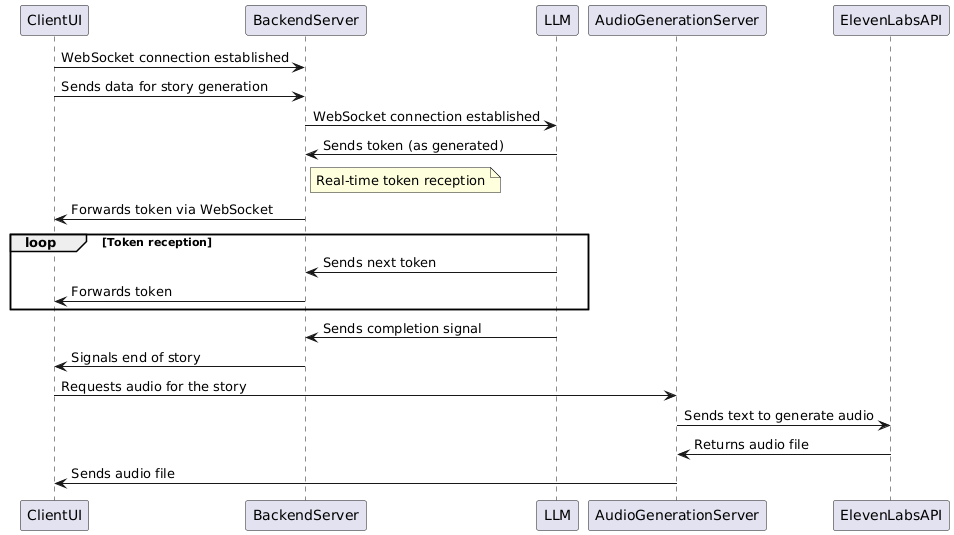




In [ ]:
from ollama import AsyncClient
from flask_socketio import SocketIO



system_promt = """
أنت نموذج ذكاء اصطناعي متخصص في إنشاء قصص موجهة للأطفال تعزز القيم الإسلامية. تتمثل مهمتك في كتابة قصة جذابة ومناسبة للفئة العمرية المحددة، مع التركيز على القيمة الأخلاقية المطلوبة. يجب أن تكون القصة مكتوبة بلغة عربية سهلة ومبسطة للأطفال، وتتضمن شخصيات وأحداث تُشجع الأطفال على تبني هذه القيمة في حياتهم اليومية.

YOU SHOULD FOLLOW THE VALUE AND THE AGE CATEGORY

"""

socketio=SocketIO()


async def chat_with_model(user_prompt, age_category, moral, sid):
    client = AsyncClient()
    try:

        messages = [
            {
                "role": "system",
                "content": system_promt,
            },
            {
                "role": "user",
                "content": f"الفئة العمرية: {age_category}, القيمة الأخلاقية: {moral}, {user_prompt}",
            },
        ]
        response = ""
        stream = await client.chat(
            model="hf.co/Raido/qween7.5-arabic-story-teller-GGUF",
            messages=messages,
            stream=True,
        )

        async for part in stream:
            socketio.emit("partial_response", {"content": response}, room=sid)
            '''The reason we are doing this is to check if the response is the last part of the story, otherwise the model will just keep generating random text'''
            if (
                re.search(r"\n### القصة:", response)
                and "\n" in part["message"]["content"]
            ):

                response += part["message"]["content"] + "." + "\n"

                break
            else:
                response += part["message"]["content"]

        return response
    except Exception as e:
        print(f"Error in chat_with_model: {str(e)}")
        socketio.emit("error", {"error": str(e)}, room=sid)
        raise

## The voice Feature 

We have used ElevenLabs api https://elevenlabs.io/api to transform our text to voice , after the LLm has completed its story generation we pass the story and its title to the api in which we get a voice file we play. 

